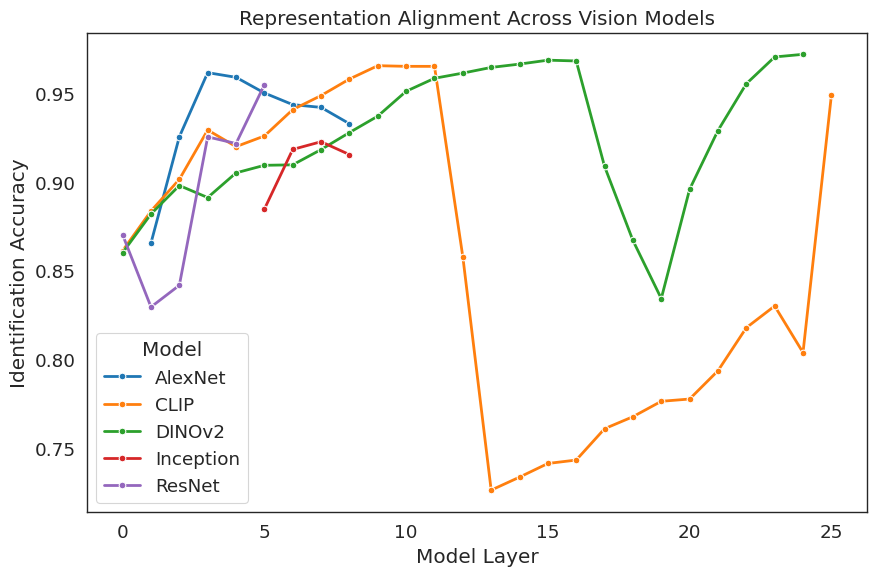

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/home/ec2-user/Brain2VLM/codes/utils/subj01_identification.csv")
df = df[df["layer"] >= 0]

sns.set_style("white")
sns.set_context("paper", font_scale=1.5)

plt.figure(figsize=(9,6))

sns.lineplot(
    data=df,
    x="layer",
    y="accuracy",
    hue="model",
    marker="o",
    linewidth=2,
    errorbar=None
)

plt.xlabel("Model Layer")
plt.ylabel("Identification Accuracy")
plt.title("Representation Alignment Across Vision Models")

plt.legend(title="Model")
plt.tight_layout()
plt.show()

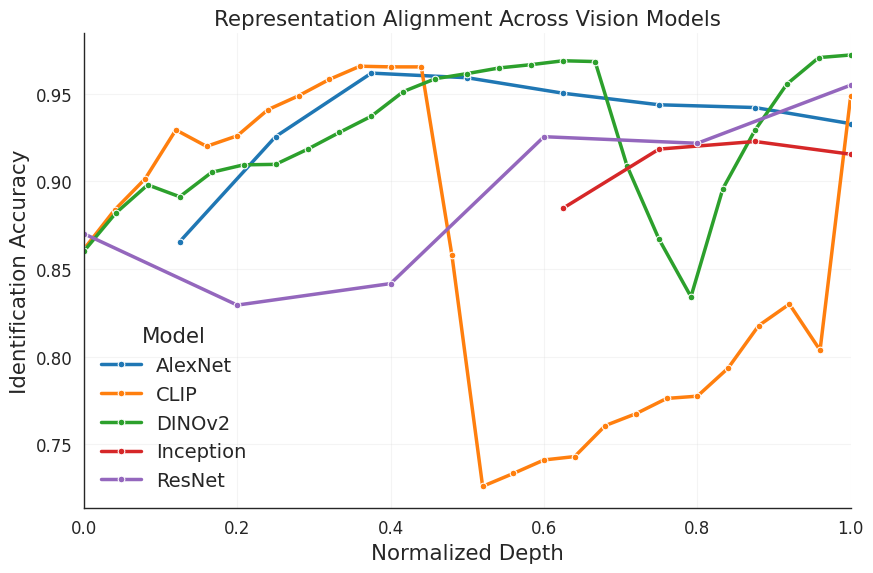

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load results
df = pd.read_csv("/home/ec2-user/Brain2VLM/codes/utils/subj01_identification.csv")

# remove invalid layers
df = df[df["layer"] >= 0]

# normalize depth within each model
df["depth"] = df.groupby("model")["layer"].transform(
    lambda x: x / x.max()
)

# sort for clean curves
df = df.sort_values(["model","depth"])

sns.set_style("white")
sns.set_context("paper", font_scale=1.6)

plt.figure(figsize=(9,6))

sns.lineplot(
    data=df,
    x="depth",
    y="accuracy",
    hue="model",
    marker="o",
    linewidth=2.5,
    errorbar=None
)

plt.grid(alpha=0.2)
plt.tick_params(axis='both', labelsize=12)

plt.xlabel("Normalized Depth")
plt.ylabel("Identification Accuracy")
plt.title("Representation Alignment Across Vision Models")

plt.legend(title="Model", frameon=False)
plt.xlim(0,1)

sns.despine()

plt.tight_layout()
plt.show()